**NAME: SABA NOOR**

**CMS: 023-24-0278**

**SECTION: H**

**LAB: 06**

**KAGGLE: https://www.kaggle.com/sabajaffar**

**GITHUB: https://github.com/SABANOOR1/Machine-Learning**

In [3]:
# Task 1: Load clean_churn.csv (or re-run your Lab 2 cleaning) and verify its shape and dtypes. 
import pandas as pd
df=pd.read_csv("clean_churn.csv")
df.shape
df.dtypes
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    
 17  Monthl

# Task 2: Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today. 
The Lab 3 Decision Tree achieved an accuracy of 80.10%, precision of 55.93%, recall of 61.68%, and F1-score of 58.67%. The Lab 4 Random Forest achieved an accuracy of 80.31%, precision of 57.95%, recall of 51.09%, and F1-score of 54.30%. These results will serve as the baseline benchmarks for today's models.

In [4]:
# Task 3: Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1). 
df=df.drop(columns=["customerID"], errors="ignore")
df["Churn"]=df["Churn"].map({"No":0,"Yes":1})
df=pd.get_dummies(df,drop_first=True)
X=df.drop("Churn", axis=1)
y=df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print(X.head())
print(y.head())

X shape: (7010, 30)
y shape: (7010,)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False       

# Task 4:  In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest. 

Feature scaling matters for KNN and Logistic Regression because they are affected by the magnitude of feature values; scaling prevents features with larger ranges from dominating the model. Decision Trees and Random Forests split data based on feature thresholds, so their decisions are not affected by differences in feature scale.    
    

In [8]:
# Task 5: Split into train/test (same split strategy as Lab 3/4), then fit a StandardScaler on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)


X_train: (5608, 30)
X_test: (1402, 30)


In [17]:
# Task 6: Train a LogisticRegression model on the scaled training data. Generate predictions on the scaled test set. 
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)

Logistic Regression Results
---------------------------
Accuracy : 0.8088445078459344
Precision: 0.6734006734006734
Recall   : 0.5390835579514824
F1-score : 0.5988023952095808


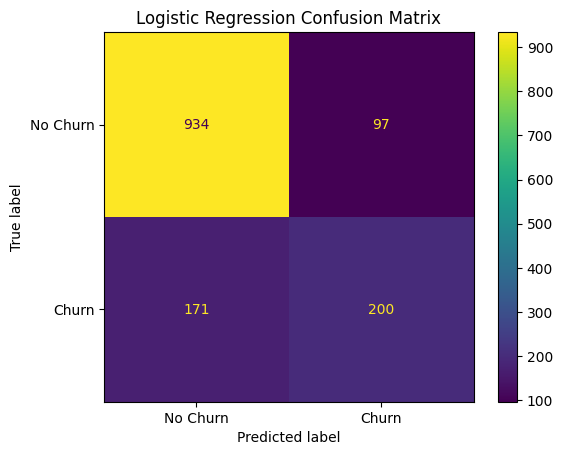

In [51]:
# Task 7: Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix. 
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

LRaccuracy=accuracy_score(y_test,y_pred)
LRprecision = precision_score(y_test, y_pred)
LRrecall = recall_score(y_test, y_pred)
LRf1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", LRaccuracy)
print("Precision:", LRprecision)
print("Recall   :", LRrecall)
print("F1-score :", LRf1)

cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [21]:
# Task 8: Look at predict_proba for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how predict() turns them into a Yes/No decision. 

probabilities=model.predict_proba(X_test_scaled)

print("Prediction probabilities:")
print(probabilities[:5])

print("Predicted Classes:")
print(model.predict(X_test_scaled[:5]))

Prediction probabilities:
[[0.63572458 0.36427542]
 [0.98649512 0.01350488]
 [0.91238377 0.08761623]
 [0.69873783 0.30126217]
 [0.74747026 0.25252974]]
Predicted Classes:
[0 0 0 0 0]


predict_proba() gives the probability of each class, where the first column represents No Churn (0) and the second represents Churn (1). predict() converts these probabilities into a class decision, normally choosing the class with the higher probability (equivalent to a 0.5 threshold for binary Logistic Regression).

In [34]:
# Task 9: Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set accuracy and F1-score for each K in a results table. 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

k_values=[1,3,5,7,9,11,15,21]
results=[]

for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled,y_train)
    y_pred_knn=knn.predict(X_test_scaled)

    accuracy=accuracy_score(y_test,y_pred_knn)
    f1=f1_score(y_test,y_pred_knn)

    results.append({
        "K": k,
        "Accuracy": accuracy,
        "F1_score": f1
    })

results_df=pd.DataFrame(results)
print(results_df)

    K  Accuracy  F1_score
0   1  0.707561  0.459103
1   3  0.737518  0.490305
2   5  0.748930  0.505618
3   7  0.762482  0.523605
4   9  0.769615  0.540541
5  11  0.771041  0.549790
6  15  0.784593  0.566092
7  21  0.780314  0.560000


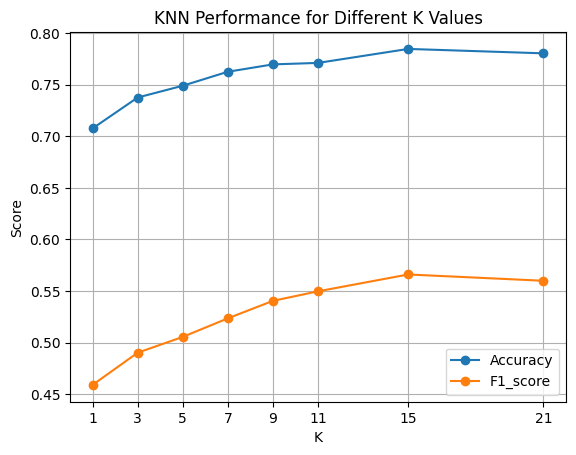

In [46]:
#Task 10: Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested? 
import matplotlib.pyplot as plt
plt.plot(results_df["K"], results_df["Accuracy"],marker="o",label="Accuracy")
plt.plot(results_df["K"],results_df["F1_score"], marker="o", label="F1_score")

plt.xlabel("K")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

Final KNN Results
-----------------
Chosen K : 15
Accuracy : 0.7845934379457917
Precision: 0.6061538461538462
Recall   : 0.5309973045822103
F1-score : 0.5660919540229885


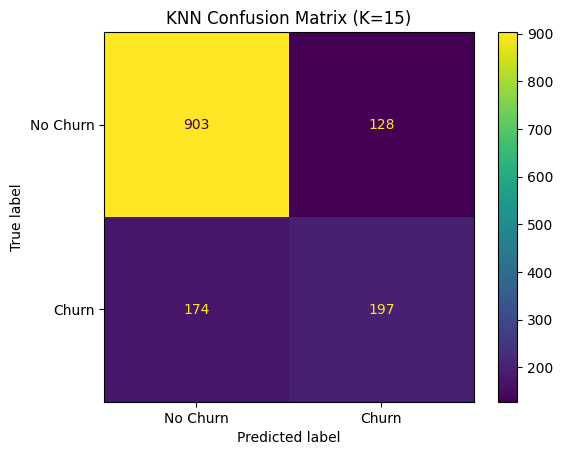

In [55]:
# Task 11: Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.
best_row = results_df.loc[results_df["F1_score"].idxmax()]
chosen_k=int(best_row["K"])
final_knn=KNeighborsClassifier(n_neighbors=chosen_k)
final_knn.fit(X_train_scaled,y_train)
y_pred_final=final_knn.predict(X_test_scaled)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

KNNaccuracy = accuracy_score(y_test, y_pred_final)
KNNprecision = precision_score(y_test, y_pred_final)
KNNrecall = recall_score(y_test, y_pred_final)
KNNf1 = f1_score(y_test, y_pred_final)

print("Final KNN Results")
print("-----------------")
print("Chosen K :", chosen_k)
print("Accuracy :", KNNaccuracy)
print("Precision:", KNNprecision)
print("Recall   :", KNNrecall)
print("F1-score :", KNNf1)

cm=confusion_matrix(y_test,y_pred_final)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title(f"KNN Confusion Matrix (K={chosen_k})")
plt.show()

In [56]:
# Task 12: 12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed). 
 
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        0.8009985734664765,
        0.8031383737517832,
        LRaccuracy,
        KNNaccuracy
    ],
    "Precision": [
        0.559322033898305,
        0.5795053003533569,
        LRprecision,
        KNNprecision
    ],
    "Recall": [
        0.616822429906542,
        0.5109034267912772,
        LRrecall,
        KNNrecall
    ],
    "F1-score": [
        0.5866666666666667,
        0.543046357615894,
        LRf1,
        KNNf1
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-score
0        Decision Tree  0.800999   0.559322  0.616822  0.586667
1        Random Forest  0.803138   0.579505  0.510903  0.543046
2  Logistic Regression  0.808845   0.673401  0.539084  0.598802
3                  KNN  0.784593   0.606154  0.530997  0.566092


# Task 13: Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

The results show that the model performance changes depending on the metric we consider. Logistic Regression has the highest accuracy (0.8088), precision (0.6734), and F1-score (0.5988). However, Decision Tree has the highest recall (0.6168), which means it identifies more of the actual churn customers.

Since the dataset has class imbalance, accuracy alone is not enough to judge the models. For this problem, recall is important because we want to identify as many customers who are likely to churn as possible. At the same time, F1-score is useful because it provides a balance between precision and recall. Therefore, I would give more attention to recall and F1-score, rather than relying only on accuracy.


In [63]:
# Task 14: Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning, holding other features constant"). 

import pandas as pd
import numpy as np

coefficients=model.coef_[0]

coef_table=pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
})

coef_table=coef_table.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coef_table)

                                  Feature  Coefficient  Odds Ratio
1                                  tenure    -1.417202    0.242391
3                            TotalCharges     0.726308    2.067434
25                      Contract_Two year    -0.571146    0.564878
10            InternetService_Fiber optic     0.517509    1.677843
2                          MonthlyCharges    -0.330064    0.718878
24                      Contract_One year    -0.279345    0.756279
26                   PaperlessBilling_Yes     0.184816    1.202997
9                       MultipleLines_Yes     0.154627    1.167222
28         PaymentMethod_Electronic check     0.149189    1.160892
19                        TechSupport_Yes    -0.142096    0.867538
21                        StreamingTV_Yes     0.139153    1.149299
23                    StreamingMovies_Yes     0.135476    1.145081
13                     OnlineSecurity_Yes    -0.133305    0.875198
0                           SeniorCitizen     0.093282    1.09

# Task 15: Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements. 

Tenure and Fiber-optic internet service came out as the two strongest features in the Decision Tree, and these were also the sharpest patterns Lab 2's EDA had already flagged — short-tenure customers and fiber customers both showed clearly higher churn rates. Contract length also lines up well, since the tree split heavily on the one-year/two-year dummy variables, matching the huge churn gap we saw by contract type in the EDA. The main disagreement is with MonthlyCharges and PaymentMethod (Electronic check), both stood out as strong churn indicators in the EDA, but they ranked much lower in the tree's feature importances. This is likely because they overlap a lot with tenure and contract type, so once the tree splits on those, the extra information from charges or payment method becomes less useful. Overall, the model confirms the biggest EDA findings but downplays a couple of features that are probably just correlated with the stronger predictors rather than being wrong.

# Task 16: Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much. 

Based on the comparison table, I selected Logistic Regression as my final model because it achieved the highest accuracy, precision, and F1-score among the four models. However, I would not rely on these results alone, because Lab 4 showed that a single test-set number does not always represent how well a model will perform on unseen data, so cross-validation should also be considered.


# Task 17: 17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

In today's comparison, Logistic Regression performed better overall than the Decision Tree and Random Forest models from Labs 3 and 4 based on accuracy and F1-score. Its accuracy was 0.8088 and its F1-score was 0.5988, compared with the Decision Tree's accuracy of 0.8010 and F1-score of 0.5867, and the Random Forest's accuracy of 0.8031 and F1-score of 0.5430. Feature scaling was important for Logistic Regression and KNN because both models are affected by the scale of the features, while tree-based models do not require scaling. The main limitation is that the dataset has class imbalance, so accuracy alone may not fully represent how well the model identifies churn customers. Logistic Regression also assumes a relatively linear relationship between the features and the log-odds of churn. As a next step, I would use cross-validation and possibly tune the model or experiment with class-balancing techniques to see whether recall and F1-score can be improved.
